# Slow-Roll Exploration for Higgs Inflation (NEQs = 6)



In [25]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



       lam3         r       n_s   alpha_s    Nefolds
0 -0.000010  0.003109  0.967412 -0.000505  57.618031
1 -0.000005  0.003168  0.967148 -0.000546  62.575615
2  0.000000  0.004461  0.961197 -0.000688  62.848423


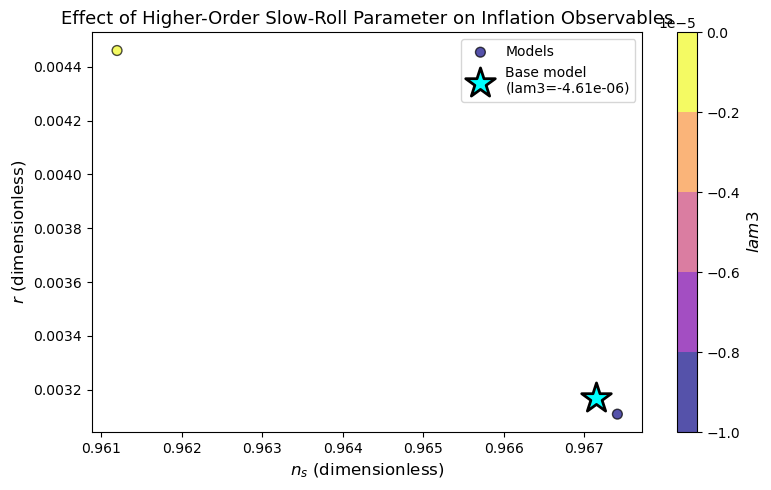

In [26]:
# 1. FUNCTION AND PLOT TO GENERATE n_s vs r


def plot_ns_r_vs_lambdaX(summary_file, lamX, base_value=None, title_prefix=None):
    """
    Plot ns vs r for a given summary file
    
    Parameters:
    -----------
    summary_file : str
        Path to CSV file with summary data
    lamX : str
        Column name for lambda parameter (e.g., "lam3")
    base_value : float, optional
        Base/reference value of lamX to highlight
    title_prefix : str, optional
        Prefix for plot title
    """
    
    # Load data
    df = pd.read_csv(summary_file)
    df_sorted = df.sort_values(lamX)

    # Discrete bins for colorbar
    bounds = np.linspace(df_sorted[lamX].min(), df_sorted[lamX].max(), 6)
    norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)

    # Plot
    plt.figure(figsize=(8,5))
    sc = plt.scatter(df["n_s"], df["r"], c=df[lamX], cmap="plasma", norm=norm,
                     alpha=0.7, edgecolor="k", s=50, label="Models")

    # Add base model marker if specified
    if base_value is not None:
        # Find closest model to base value
        idx_base = (df[lamX] - base_value).abs().idxmin()
        base_ns = df.loc[idx_base, "n_s"]
        base_r = df.loc[idx_base, "r"]
        
        # Plot base model with distinct marker
        plt.scatter(base_ns, base_r, 
                   marker='*', s=500, 
                   color='cyan', edgecolor='black', linewidth=2,
                   label=f'Base model\n({lamX}={base_value:.2e})',
                   zorder=10)  # zorder ensures it's on top

    # Colorbar
    cbar = plt.colorbar(sc, boundaries=bounds, ticks=bounds)
    cbar.set_label(rf"${lamX}$", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # Labels and style
    plt.xlabel(r"$n_s$ (dimensionless)", fontsize=12)
    plt.ylabel(r"$r$ (dimensionless)", fontsize=12)
    title_prefix = title_prefix if title_prefix is not None else lamX
    plt.title(rf"Effect of Higher-Order Slow-Roll Parameter "
              rf"on Inflation Observables", fontsize=13)
    
    if base_value is not None:
        plt.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()

summary_file_neqs6 = f"/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/neqs6_summary.csv"

summary_df_neqs6 = pd.read_csv(summary_file_neqs6)
print(summary_df_neqs6.head())

# Call with base value
plot_ns_r_vs_lambdaX(summary_file_neqs6, "lam3", 
                     base_value=-4.60971e-6,  # Your base λ₃
                     title_prefix="NEQS=6")


In [38]:
# 2. Check lam3, r, n_s, alpha_s, Nefolds

def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    """
    Scan directories for parameter values and optionally show summary statistics
    
    Parameters:
    -----------
    NEQS : int
        Number of equations (e.g., 6)
    param_name : str
        Parameter name (e.g., "lam3")
    base_path_root : str
        Root path to search
    show_summary : bool
        If True, print summary information about models found
    
    Returns:
    --------
    list of tuples
        [(value, label), ...] for each parameter value found
    """
    
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []
    for d in dirs:
        try:
            # lam3_-4.6e-06 → "-4.6e-06"
            val_str = os.path.basename(d).split("_")[1]
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")
    
    # Sort by parameter value
    values.sort(key=lambda x: x[0])
    
    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        print(f"{'='*60}\n")
    
    return values


# Usage
base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)
# lam3_values = np.array(lam3_values)
print(lam3_values)


Summary for NEQS=6, parameter=lam3
Total models found: 3
Parameter range: -1.000e-05 to 0.000e+00

[(-1e-05, '$lam3 = -1.0e-05$'), (-4.6e-06, '$lam3 = -4.6e-06$'), (0.0, '$lam3 = 0.0e+00$')]


A Brief Check that every column has a value man!

In [35]:
# Load one file and print first few rows to see the structure
sample_file = f"{base_path_root}/neqs6/lam3_-4.6e-06/path_neqs6_lam3-4.6e-06_000.dat"
df = pd.read_csv(sample_file, sep=r'\s+', header=None)

print("File shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn count:", len(df.columns))
print("\nExpected structure:")
print("  Cols 0-5: [phi, H, eps, sigma, lam2, lam3] (state vector)")
print("  Col 6: N (e-folds)")
print("  Cols 7+: ???")

print("\nLast 3 rows:")
print(df.tail(3))


print("\nCheck if epsilon is calculated:")
print("Col 5 value range:", df[5].min(), "to", df[5].max())


File shape: (99, 9)

First 3 rows:
          0             1         2         3         4         5         6  \
0  1.094771  5.424104e-07  0.999985 -5.177708  0.240852 -0.050904  0.000005   
1  1.094769  5.424131e-07  0.999969 -5.177636  0.240849 -0.050903  0.000010   
2  1.094762  5.424266e-07  0.999890 -5.177277  0.240832 -0.050898  0.000035   

              7             8  
0  2.341259e-14  1.170603e-14  
1  2.341301e-14  1.170596e-14  
2  2.341511e-14  1.170561e-14  

Column count: 9

Expected structure:
  Cols 0-5: [phi, H, eps, sigma, lam2, lam3] (state vector)
  Col 6: N (e-folds)
  Cols 7+: ???

Last 3 rows:
           0         1         2         3         4         5          6  \
96  0.016031  0.000001  0.000226 -0.035582  0.000300 -0.000005  58.662731   
97  0.002968  0.000001  0.000202 -0.033662  0.000270 -0.000004  61.831396   
98  0.000000  0.000001  0.000197 -0.033240  0.000263 -0.000004  62.575615   

               7             8  
96  1.873012e-13  1.408088e-17

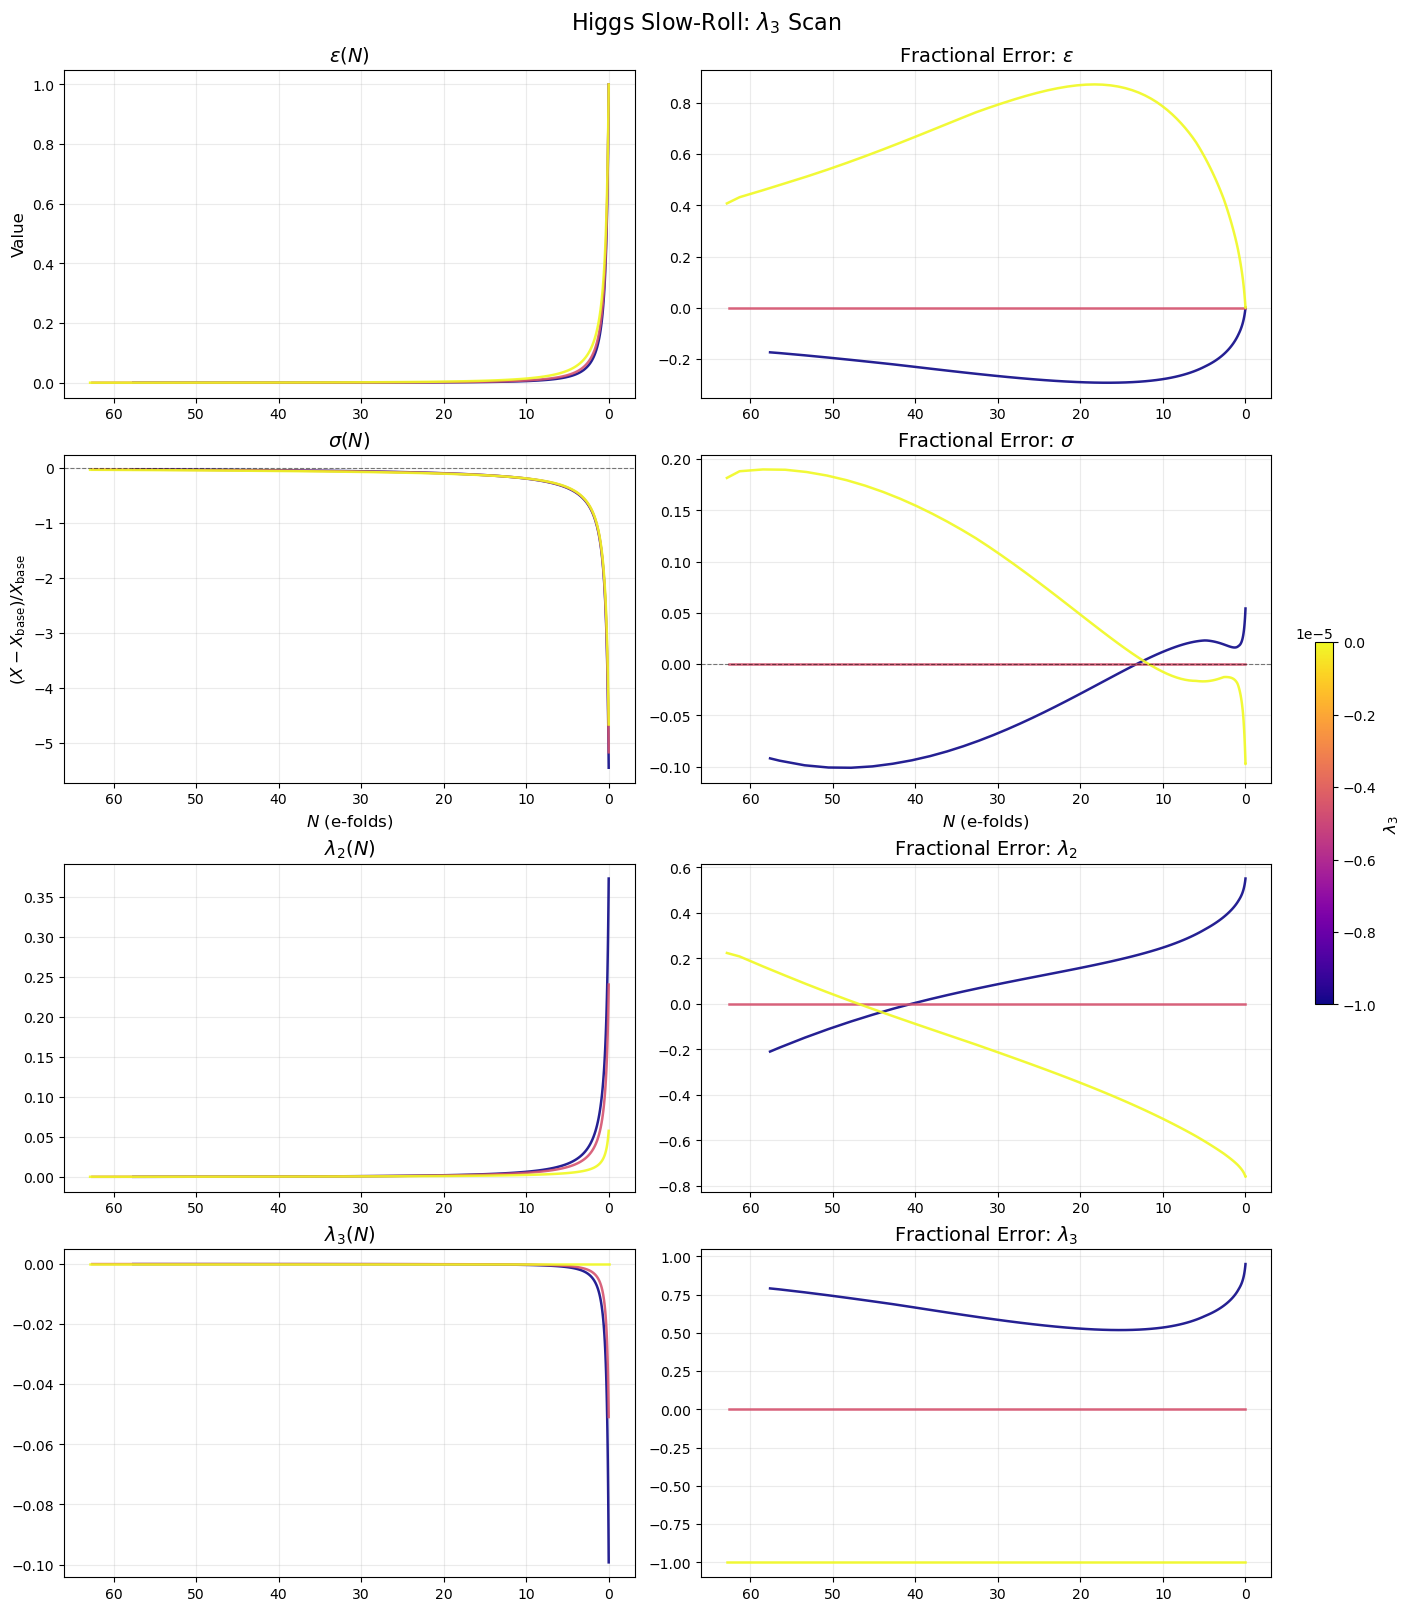

In [43]:
# 3. epsilon(N), sigma(N), 2lambda(N), 3lambda(N) with fractional errors

def plot_slowroll_variations_with_errors(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    save_name=None,
    suptitle=None,
):
    """
    Plot slow-roll parameters (eps, sigma, lam2, lam3) vs N,
    with fractional error relative to base model below each.
    
    Layout: 2x4
      Top row: eps(N), sigma(N), lam2(N), lam3(N)
      Bottom row: fractional errors for each
    """
    base_path = f"{base_path_root}/neqs{NEQS}"
    
    # Column indices 
    col_N = 6
    col_eps = 2      
    col_sigma = 3
    col_lam2 = 4
    col_lam3 = 5
    
    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)
    
    def load_path_lam3(value, index=index):
        val_str = f"{value:.1e}"  # ← Changed from .5e to .1e
        file_path = (
            f"{base_path}/lam3_{val_str}/"
            f"path_neqs{NEQS}_lam3{val_str}_{index:03d}.dat"
        )
        return pd.read_csv(file_path, sep=r'\s+', header=None).values

    
    # Load base model
    try:
        base_data = load_path_lam3(base_lam3)
        N_base = base_data[:, col_N]
        eps_base = base_data[:, col_eps]
        sigma_base = base_data[:, col_sigma]
        lam2_base = base_data[:, col_lam2]
        lam3_base = base_data[:, col_lam3]
    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return
    
    # Colormap
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    
#     fig, axs = plt.subplots(2, 4, figsize=(20, 8), constrained_layout=True)
    fig, axs = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)
    
    for lam3_val in lam3_numeric:
        try:
            data = load_path_lam3(lam3_val)
            N = data[:, col_N]
            eps = data[:, col_eps]
            sigma = data[:, col_sigma]
            lam2 = data[:, col_lam2]
            lam3 = data[:, col_lam3]
            
            color = cmap(norm(lam3_val))
            
            # Interpolate base values to match current N grid
            eps_base_interp = np.interp(N, N_base, eps_base)
            sigma_base_interp = np.interp(N, N_base, sigma_base)
            lam2_base_interp = np.interp(N, N_base, lam2_base)
            lam3_base_interp = np.interp(N, N_base, lam3_base)
            
            # Fractional errors
            frac_eps = (eps - eps_base_interp) / eps_base_interp
            frac_sigma = (sigma - sigma_base_interp) / sigma_base_interp
            frac_lam2 = (lam2 - lam2_base_interp) / lam2_base_interp
            frac_lam3 = (lam3 - lam3_base_interp) / lam3_base_interp
            
            axs[0, 0].plot(N, eps, color=color, lw=1.8, alpha=0.9)
            axs[0, 1].plot(N, frac_eps, color=color, lw=1.8, alpha=0.9)

            axs[1, 0].plot(N, sigma, color=color, lw=1.8, alpha=0.9)
            axs[1, 1].plot(N, frac_sigma, color=color, lw=1.8, alpha=0.9)

            axs[2, 0].plot(N, lam2, color=color, lw=1.8, alpha=0.9)
            axs[2, 1].plot(N, frac_lam2, color=color, lw=1.8, alpha=0.9)

            axs[3, 0].plot(N, lam3, color=color, lw=1.8, alpha=0.9)
            axs[3, 1].plot(N, frac_lam3, color=color, lw=1.8, alpha=0.9)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")
    
    # Titles
    axs[0, 0].set_title(r"$\epsilon(N)$", fontsize=14)
    axs[1, 0].set_title(r"$\sigma(N)$", fontsize=14)
    axs[2, 0].set_title(r"$\lambda_2(N)$", fontsize=14)
    axs[3, 0].set_title(r"$\lambda_3(N)$", fontsize=14)
    
    axs[0, 1].set_title(r"Fractional Error: $\epsilon$", fontsize=14)
    axs[1, 1].set_title(r"Fractional Error: $\sigma$", fontsize=14)
    axs[2, 1].set_title(r"Fractional Error: $\lambda_2$", fontsize=14)
    axs[3, 1].set_title(r"Fractional Error: $\lambda_3$", fontsize=14)
    
    # Y-labels
    axs[0, 0].set_ylabel("Value", fontsize=12)
    axs[1, 0].set_ylabel(r"$(X - X_{\rm base}) / X_{\rm base}$", fontsize=12)
    
    # X-labels (only bottom row)
    for ax in axs[1, :]:
        ax.set_xlabel(r"$N$ (e-folds)", fontsize=12)
    
    # Invert x-axis (N decreases toward end of inflation)
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)
    
    # Add horizontal line at 0 for error plots
    for ax in axs[1, :]:
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Colorbar
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), orientation="vertical", 
                        fraction=0.015, pad=0.02)
    cbar.set_label(r"$\lambda_3$", fontsize=12)
    
    # Suptitle
    if suptitle is None:
        suptitle = r"Slow-Roll Parameters vs $\lambda_3$ Variations"
    fig.suptitle(suptitle, fontsize=16)
    
    # Save
    if save_name is None:
        save_name = f"neqs{NEQS}_slowroll_lam3_variations.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()


plot_slowroll_variations_with_errors(
    NEQS=6, 
    lam3_values=lam3_values, 
    base_lam3=-4.6e-6, 
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    save_name="higgs_slowroll_variations.png",
    suptitle=r"Higgs Slow-Roll: $\lambda_3$ Scan"
)


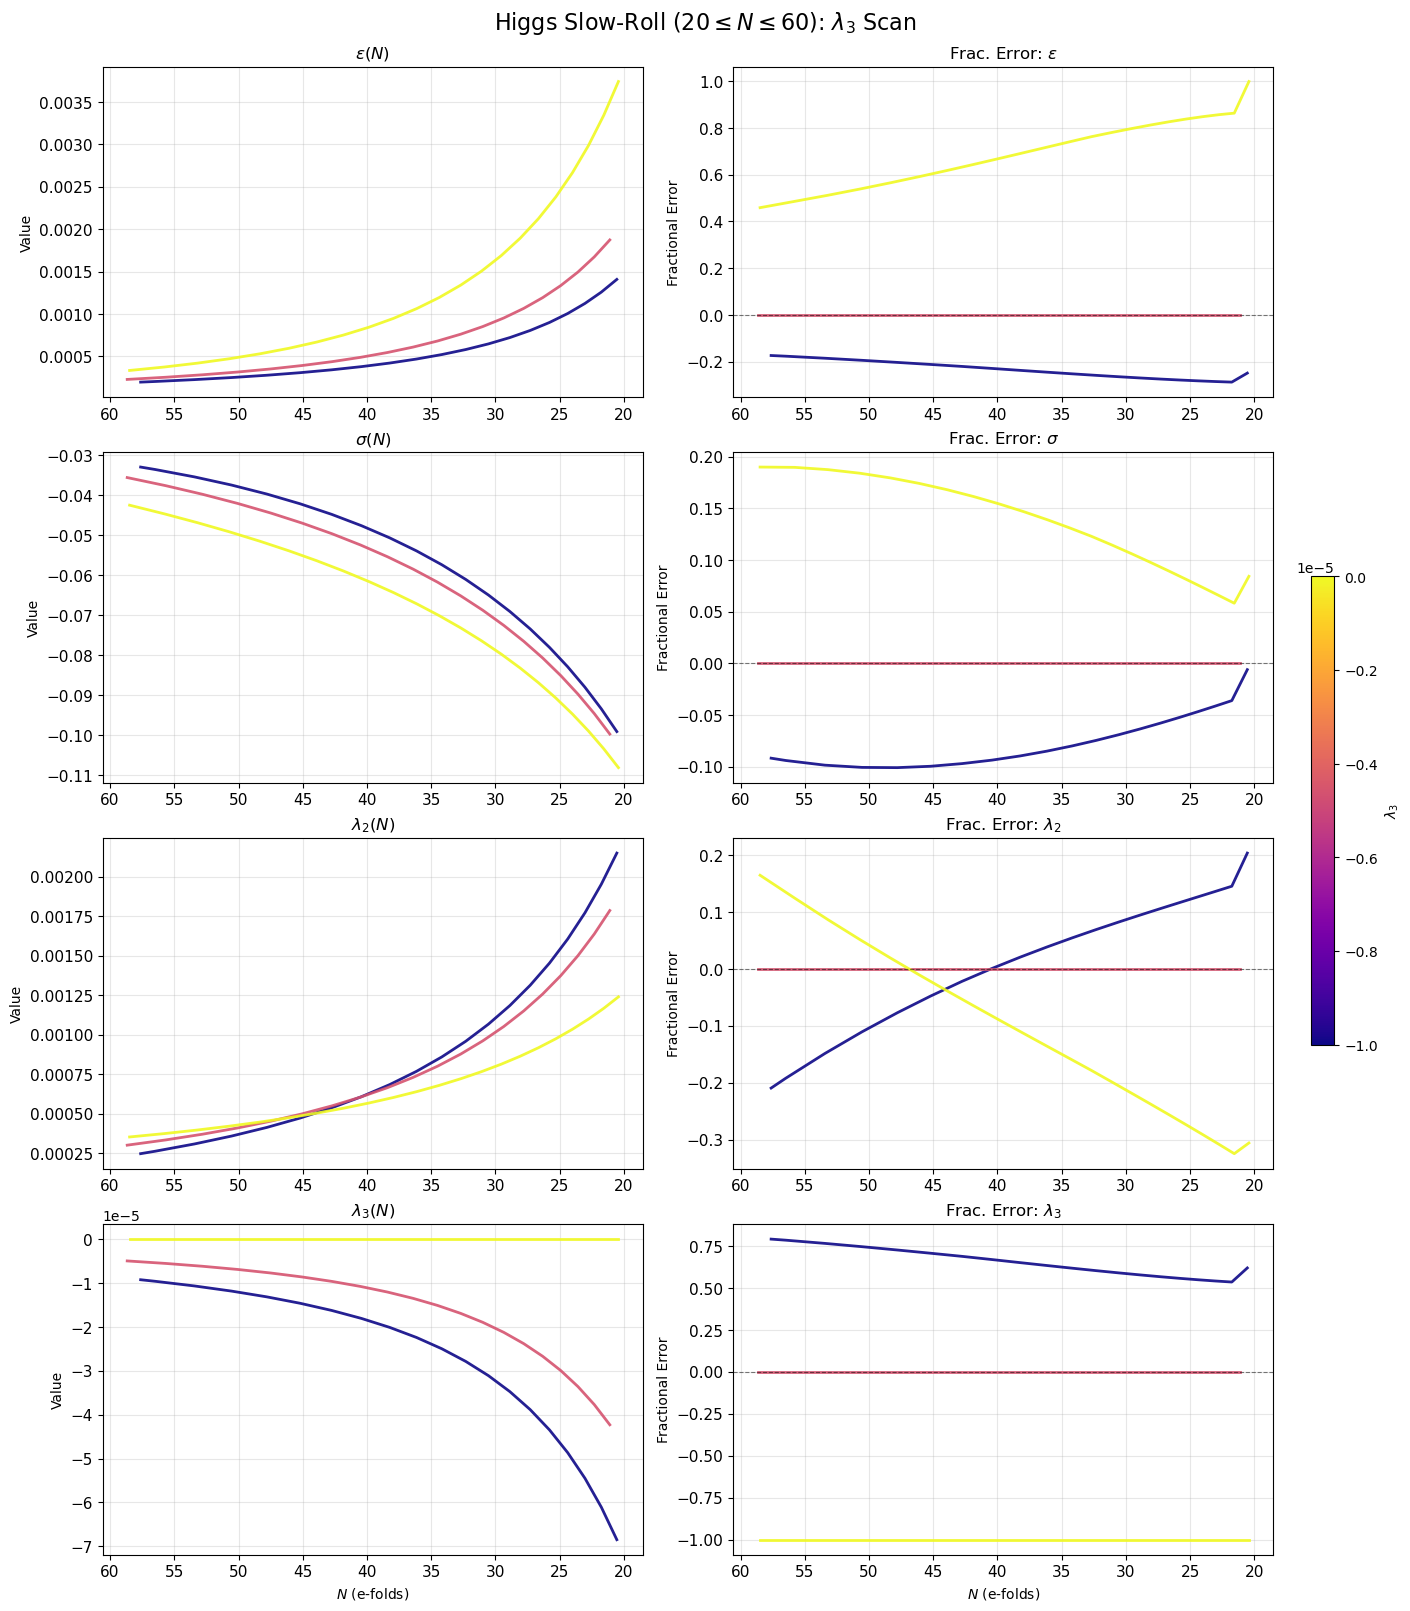

In [65]:
def plot_slowroll_variations_with_errors_limitedN(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    save_name=None,
    suptitle=None,
):
    """
    Plot slow-roll parameters (eps, sigma, lam2, lam3) vs N,
    restricted to 20 <= N <= 60, with fractional errors.
    """

    base_path = f"{base_path_root}/neqs{NEQS}"

    # Column indices 
    col_N = 6
    col_eps = 2      
    col_sigma = 3
    col_lam2 = 4
    col_lam3 = 5

    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)

    def load_path_lam3(value, index=index):
        val_str = f"{value:.1e}"
        file_path = (
            f"{base_path}/lam3_{val_str}/"
            f"path_neqs{NEQS}_lam3{val_str}_{index:03d}.dat"
        )
        return pd.read_csv(file_path, sep=r'\s+', header=None).values

    # --- Load base model ---
    try:
        base_data = load_path_lam3(base_lam3)

        N_base = base_data[:, col_N]
        eps_base = base_data[:, col_eps]
        sigma_base = base_data[:, col_sigma]
        lam2_base = base_data[:, col_lam2]
        lam3_base = base_data[:, col_lam3]

        # Apply mask to base
        mask_base = (N_base <= 60) & (N_base >= 20)

        N_base = N_base[mask_base]
        eps_base = eps_base[mask_base]
        sigma_base = sigma_base[mask_base]
        lam2_base = lam2_base[mask_base]
        lam3_base = lam3_base[mask_base]

    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return

    # --- Colormap ---
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    # --- Figure ---
    fig, axs = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            data = load_path_lam3(lam3_val)

            N = data[:, col_N]
            eps = data[:, col_eps]
            sigma = data[:, col_sigma]
            lam2 = data[:, col_lam2]
            lam3 = data[:, col_lam3]

            # Apply mask
            mask = (N <= 60) & (N >= 20)

            N = N[mask]
            eps = eps[mask]
            sigma = sigma[mask]
            lam2 = lam2[mask]
            lam3 = lam3[mask]

            color = cmap(norm(lam3_val))

            # Interpolate base onto current N grid
            eps_base_interp = np.interp(N, N_base, eps_base)
            sigma_base_interp = np.interp(N, N_base, sigma_base)
            lam2_base_interp = np.interp(N, N_base, lam2_base)
            lam3_base_interp = np.interp(N, N_base, lam3_base)

            # Avoid divide-by-zero issues
            tiny = 1e-30
            frac_eps = (eps - eps_base_interp) / np.where(np.abs(eps_base_interp) > tiny, eps_base_interp, np.nan)
            frac_sigma = (sigma - sigma_base_interp) / np.where(np.abs(sigma_base_interp) > tiny, sigma_base_interp, np.nan)
            frac_lam2 = (lam2 - lam2_base_interp) / np.where(np.abs(lam2_base_interp) > tiny, lam2_base_interp, np.nan)
            frac_lam3 = (lam3 - lam3_base_interp) / np.where(np.abs(lam3_base_interp) > tiny, lam3_base_interp, np.nan)

            # --- Plot ---
            axs[0, 0].plot(N, eps, color=color, lw=2.0, alpha=0.9)
            axs[0, 1].plot(N, frac_eps, color=color, lw=2.0, alpha=0.9)

            axs[1, 0].plot(N, sigma, color=color, lw=2.0, alpha=0.9)
            axs[1, 1].plot(N, frac_sigma, color=color, lw=2.0, alpha=0.9)

            axs[2, 0].plot(N, lam2, color=color, lw=2.0, alpha=0.9)
            axs[2, 1].plot(N, frac_lam2, color=color, lw=2.0, alpha=0.9)

            axs[3, 0].plot(N, lam3, color=color, lw=2.0, alpha=0.9)
            axs[3, 1].plot(N, frac_lam3, color=color, lw=2.0, alpha=0.9)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    # --- Titles ---
    axs[0, 0].set_title(r"$\epsilon(N)$")
    axs[1, 0].set_title(r"$\sigma(N)$")
    axs[2, 0].set_title(r"$\lambda_2(N)$")
    axs[3, 0].set_title(r"$\lambda_3(N)$")

    axs[0, 1].set_title(r"Frac. Error: $\epsilon$")
    axs[1, 1].set_title(r"Frac. Error: $\sigma$")
    axs[2, 1].set_title(r"Frac. Error: $\lambda_2$")
    axs[3, 1].set_title(r"Frac. Error: $\lambda_3$")

    # --- Labels ---
    for i in range(4):
        axs[i, 0].set_ylabel("Value")
        axs[i, 1].set_ylabel("Fractional Error")

    for ax in axs[-1, :]:
        ax.set_xlabel(r"$N$ (e-folds)")

    # --- Styling ---
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=11)

    for ax in axs[:, 1]:
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # --- Colorbar ---
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label(r"$\lambda_3$")

    # --- Title ---
    if suptitle is None:
        suptitle = r"Slow-Roll Parameters (20 ≤ N ≤ 60)"
    fig.suptitle(suptitle, fontsize=16)

    # --- Save ---
    if save_name is None:
        save_name = f"neqs{NEQS}_slowroll_zoomed.png"

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    
    
plot_slowroll_variations_with_errors_limitedN(
NEQS=6,
lam3_values=lam3_values,
base_lam3=-4.6e-6,
base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
index=0,
save_name="higgs_slowroll_variations_zoomed.png",
suptitle=r"Higgs Slow-Roll ($20 \leq N \leq 60$): $\lambda_3$ Scan"
)

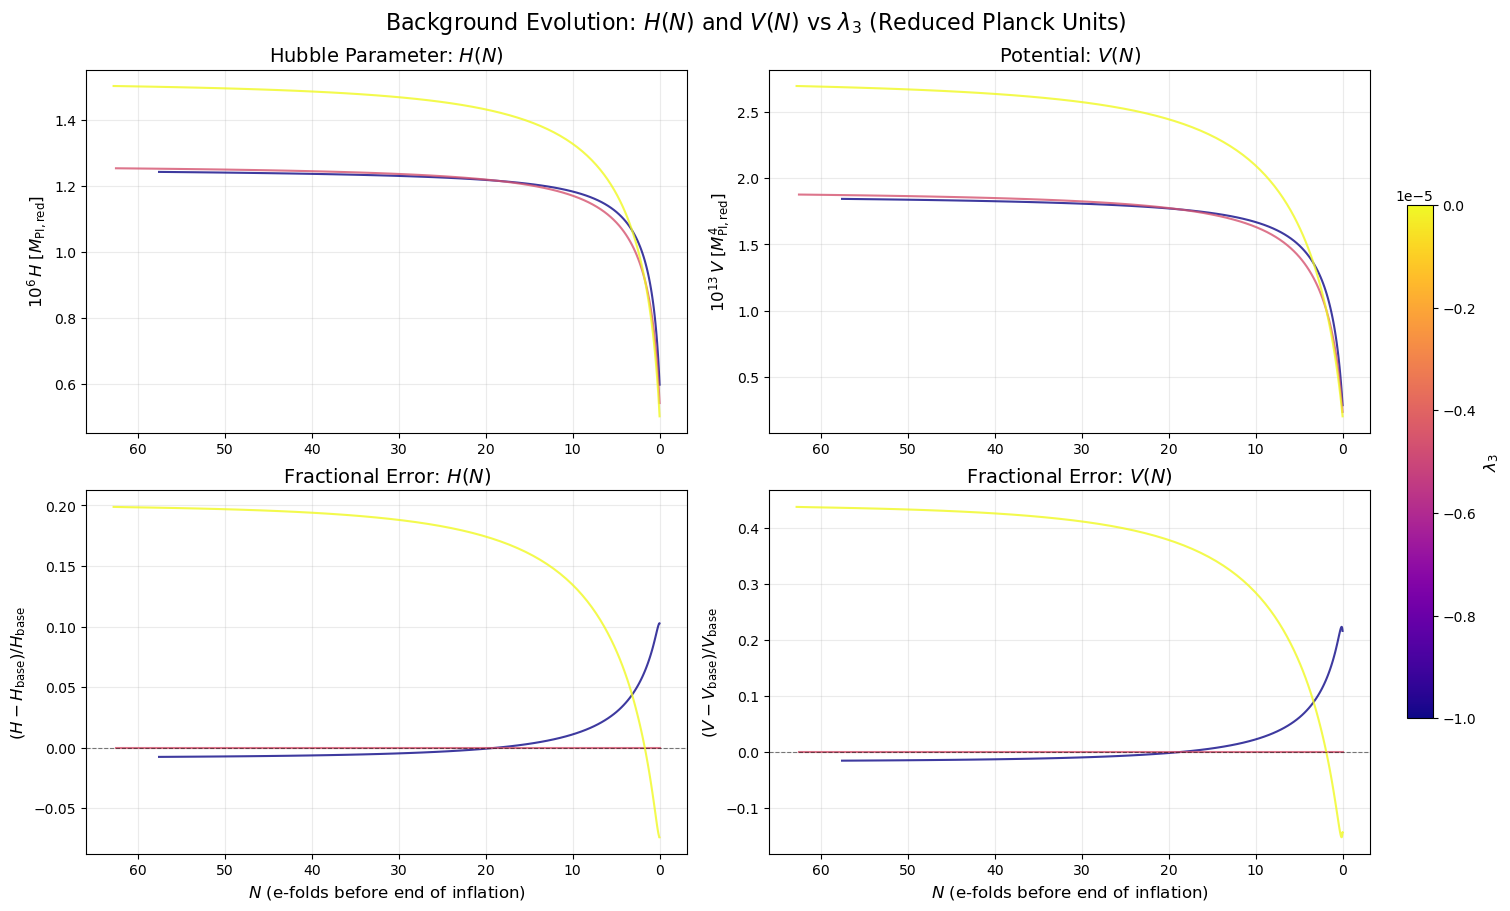

In [47]:
# 4. H(N), V(N) with fractional errors

def plot_HV_with_errors(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    scale_H=1e6,
    scale_V=1e13,
    save_name=None,
    suptitle=None,
):
    """
    Plot H(N) and V(N) with fractional errors relative to base model.
    
    Layout: 2x2
      Top row: H(N), V(N)
      Bottom row: fractional error H(N), fractional error V(N)
    
    Conventions / units:
      - Reduced Planck units: M_pl,red = 1
      - N is dimensionless (e-folds before end of inflation)
      - H is in M_pl,red
      - V is in M_pl,red^4
    """
    base_path = f"{base_path_root}/neqs{NEQS}"
    col_H, col_N, col_V = 1, NEQS, NEQS + 1

    def load_path_lam3(value, index=index):
        val_str = f"{value:.1e}"  # ← Changed from .5e to .1e
        file_path = (
            f"{base_path}/lam3_{val_str}/"
            f"path_neqs{NEQS}_lam3{val_str}_{index:03d}.dat"
        )
        return pd.read_csv(file_path, sep=r'\s+', header=None).values

    # Load base model
    try:
        base_data = load_path_lam3(base_lam3)
        N_base = base_data[:, col_N]
        H_base = base_data[:, col_H]
        V_base = base_data[:, col_V]
    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return

    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)

        
    # Colormap
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    fig, axs = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            data = load_path_lam3(lam3_val)
            N = data[:, col_N]
            H = data[:, col_H]
            V = data[:, col_V]

            color = cmap(norm(lam3_val))

            # Interpolate base values to match current N grid
            H_base_interp = np.interp(N, N_base, H_base)
            V_base_interp = np.interp(N, N_base, V_base)

            # Fractional errors
            frac_H = (H - H_base_interp) / H_base_interp
            frac_V = (V - V_base_interp) / V_base_interp

            # Top row: actual values
            axs[0, 0].plot(N, scale_H * H, color=color, lw=1.5, alpha=0.8)
            axs[0, 1].plot(N, scale_V * V, color=color, lw=1.5, alpha=0.8)

            # Bottom row: fractional errors
            axs[1, 0].plot(N, frac_H, color=color, lw=1.5, alpha=0.8)
            axs[1, 1].plot(N, frac_V, color=color, lw=1.5, alpha=0.8)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    # Top row titles
    axs[0, 0].set_title(r"Hubble Parameter: $H(N)$", fontsize=14)
    axs[0, 1].set_title(r"Potential: $V(N)$", fontsize=14)

    # Bottom row titles
    axs[1, 0].set_title(r"Fractional Error: $H(N)$", fontsize=14)
    axs[1, 1].set_title(r"Fractional Error: $V(N)$", fontsize=14)

    # Y-labels
    axs[0, 0].set_ylabel(rf"$10^{{{int(np.log10(scale_H))}}}\,H \;[M_{{\rm Pl,red}}]$", fontsize=12)
    axs[0, 1].set_ylabel(rf"$10^{{{int(np.log10(scale_V))}}}\,V \;[M_{{\rm Pl,red}}^4]$", fontsize=12)
    axs[1, 0].set_ylabel(r"$(H - H_{\rm base}) / H_{\rm base}$", fontsize=12)
    axs[1, 1].set_ylabel(r"$(V - V_{\rm base}) / V_{\rm base}$", fontsize=12)

    # X-labels (only bottom row)
    axs[1, 0].set_xlabel(r"$N$ (e-folds before end of inflation)", fontsize=12)
    axs[1, 1].set_xlabel(r"$N$ (e-folds before end of inflation)", fontsize=12)

    # Invert x-axis (N decreases toward end of inflation)
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

    # Add horizontal line at 0 for error plots
    axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # Colorbar
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), orientation="vertical", 
                        fraction=0.02, pad=0.02)
    cbar.set_label(r"$\lambda_3$", fontsize=12)

    # Suptitle
    if suptitle is None:
        suptitle = r"Background Evolution: $H(N)$ and $V(N)$ vs $\lambda_3$ (Reduced Planck Units)"
    fig.suptitle(suptitle, fontsize=16)

    # Save
    if save_name is None:
        save_name = f"neqs{NEQS}_HV_lam3_variations.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

    
plot_HV_with_errors(
    NEQS=6,
    lam3_values=lam3_values,
    base_lam3=-4.6e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
)


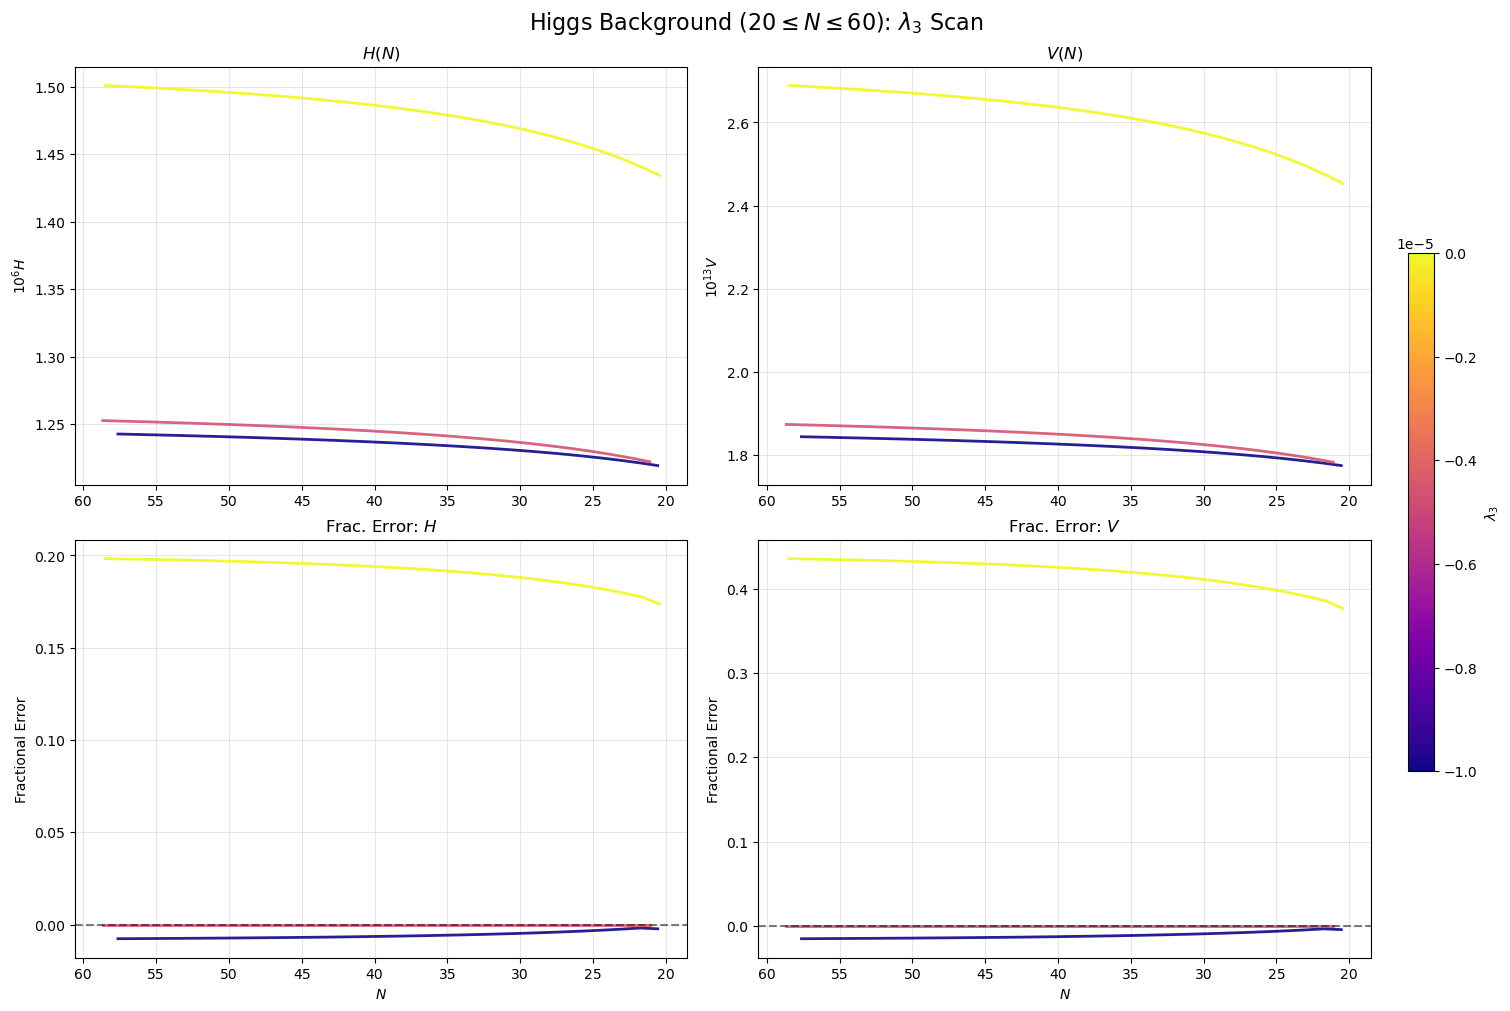

In [66]:
def plot_HV_with_errors_limitedN(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    scale_H=1e6,
    scale_V=1e13,
    save_name=None,
    suptitle=None,
):
    """
    Plot H(N) and V(N) with fractional errors, restricted to 20 <= N <= 60.
    """

    base_path = f"{base_path_root}/neqs{NEQS}"
    col_H, col_N, col_V = 1, NEQS, NEQS + 1

    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)

    def load_path_lam3(value, index=index):
        val_str = f"{value:.1e}"
        file_path = (
            f"{base_path}/lam3_{val_str}/"
            f"path_neqs{NEQS}_lam3{val_str}_{index:03d}.dat"
        )
        return pd.read_csv(file_path, sep=r'\s+', header=None).values

    # --- Load base model ---
    try:
        base_data = load_path_lam3(base_lam3)

        N_base = base_data[:, col_N]
        H_base = base_data[:, col_H]
        V_base = base_data[:, col_V]

        # Apply mask
        mask_base = (N_base <= 60) & (N_base >= 20)

        N_base = N_base[mask_base]
        H_base = H_base[mask_base]
        V_base = V_base[mask_base]

    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return

    # --- Colormap ---
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            data = load_path_lam3(lam3_val)

            N = data[:, col_N]
            H = data[:, col_H]
            V = data[:, col_V]

            # Apply mask
            mask = (N <= 60) & (N >= 20)

            N = N[mask]
            H = H[mask]
            V = V[mask]

            color = cmap(norm(lam3_val))

            # Interpolate base
            H_base_interp = np.interp(N, N_base, H_base)
            V_base_interp = np.interp(N, N_base, V_base)

            tiny = 1e-30
            frac_H = (H - H_base_interp) / np.where(np.abs(H_base_interp) > tiny, H_base_interp, np.nan)
            frac_V = (V - V_base_interp) / np.where(np.abs(V_base_interp) > tiny, V_base_interp, np.nan)

            # --- Plot ---
            axs[0, 0].plot(N, scale_H * H, color=color, lw=2.0, alpha=0.9)
            axs[0, 1].plot(N, scale_V * V, color=color, lw=2.0, alpha=0.9)

            axs[1, 0].plot(N, frac_H, color=color, lw=2.0, alpha=0.9)
            axs[1, 1].plot(N, frac_V, color=color, lw=2.0, alpha=0.9)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    # --- Titles ---
    axs[0, 0].set_title(r"$H(N)$")
    axs[0, 1].set_title(r"$V(N)$")
    axs[1, 0].set_title(r"Frac. Error: $H$")
    axs[1, 1].set_title(r"Frac. Error: $V$")

    # --- Labels ---
    axs[0, 0].set_ylabel(rf"$10^{{{int(np.log10(scale_H))}}} H$")
    axs[0, 1].set_ylabel(rf"$10^{{{int(np.log10(scale_V))}}} V$")
    axs[1, 0].set_ylabel("Fractional Error")
    axs[1, 1].set_ylabel("Fractional Error")

    axs[1, 0].set_xlabel(r"$N$")
    axs[1, 1].set_xlabel(r"$N$")

    # --- Styling ---
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)

    axs[1, 0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axs[1, 1].axhline(0, color='black', linestyle='--', alpha=0.5)

    # --- Colorbar ---
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label(r"$\lambda_3$")

    # --- Title ---
    if suptitle is None:
        suptitle = r"$H(N)$ and $V(N)$ (20 ≤ N ≤ 60)"
    fig.suptitle(suptitle, fontsize=16)

    # --- Save ---
    if save_name is None:
        save_name = f"neqs{NEQS}_HV_zoomed.png"

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    
    
plot_HV_with_errors_limitedN(
NEQS=6,
lam3_values=lam3_values,
base_lam3=-4.6e-6,
base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
save_name="higgs_HV_zoomed.png",
suptitle=r"Higgs Background ($20 \leq N \leq 60$): $\lambda_3$ Scan"
)

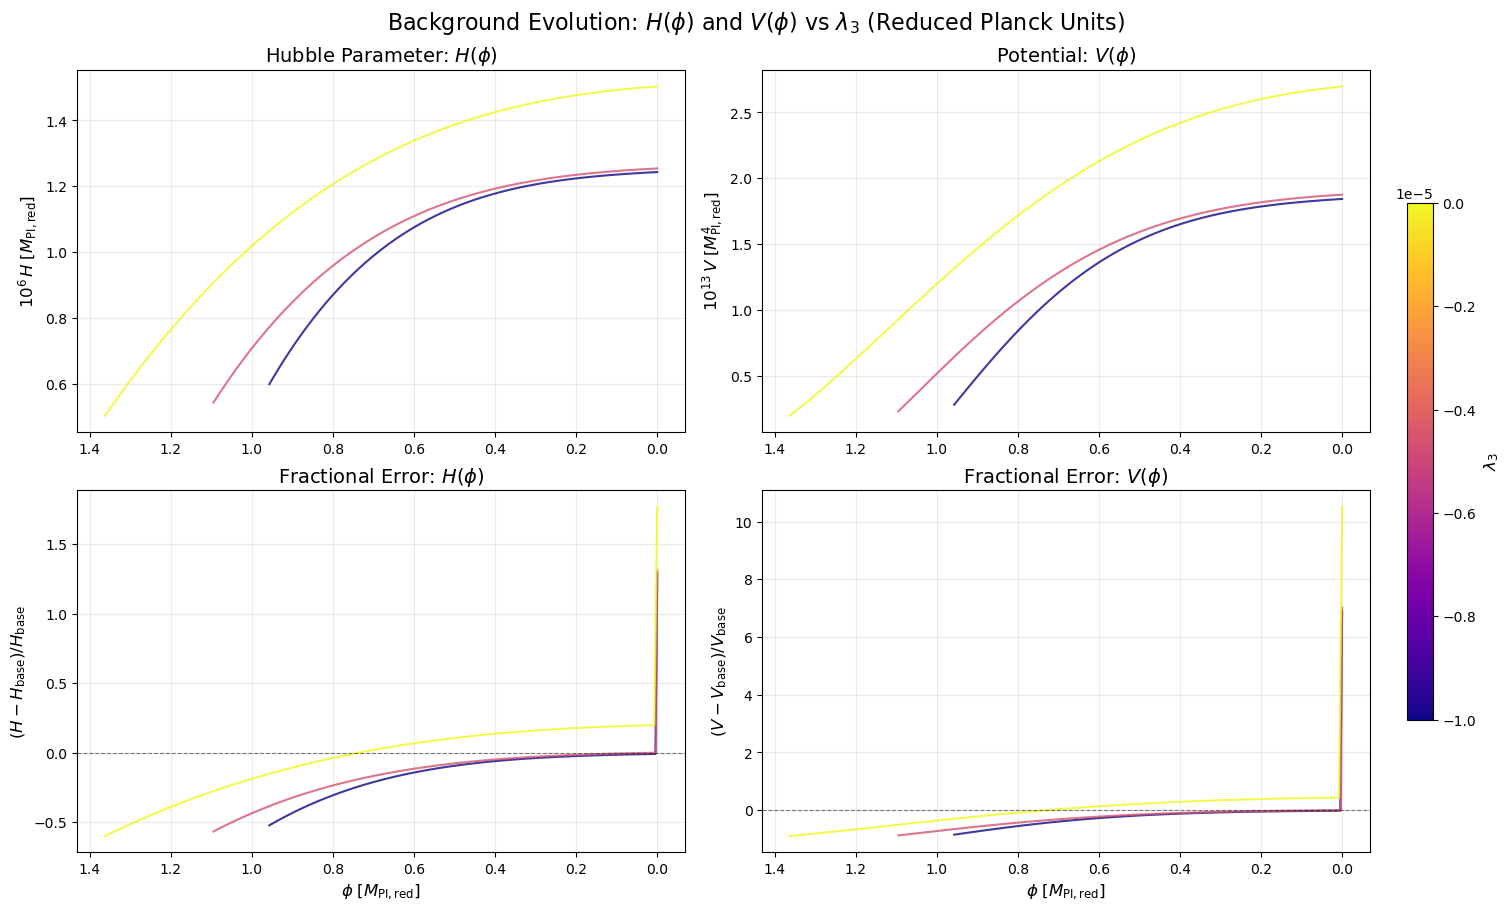

In [49]:
# 5. H(phi), V(phi) with fractional errors


def plot_HV_phi_with_errors(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    scale_H=1e6,
    scale_V=1e13,
    save_name=None,
    suptitle=None,
):
    """
    Plot H(phi) and V(phi) with fractional errors relative to base model.
    
    Layout: 2x2
      Top row: H(phi), V(phi)
      Bottom row: fractional error H(phi), fractional error V(phi)
    
    Conventions / units:
      - Reduced Planck units: M_pl,red = 1
      - phi is in M_pl,red
      - H is in M_pl,red
      - V is in M_pl,red^4
    """
    base_path = f"{base_path_root}/neqs{NEQS}"
    col_phi, col_H, col_V = 0, 1, NEQS + 1

    def load_path_lam3(value, index=index):
        val_str = f"{value:.1e}"  # ← Changed from .5e to .1e
        file_path = (
            f"{base_path}/lam3_{val_str}/"
            f"path_neqs{NEQS}_lam3{val_str}_{index:03d}.dat"
        )
        return pd.read_csv(file_path, sep=r'\s+', header=None).values

        
    # Load base model
    try:
        base_data = load_path_lam3(base_lam3)
        phi_base = base_data[:, col_phi]
        H_base = base_data[:, col_H]
        V_base = base_data[:, col_V]
    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return

    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)
        
    # Colormap
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    fig, axs = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            data = load_path_lam3(lam3_val)
            phi = data[:, col_phi]
            H = data[:, col_H]
            V = data[:, col_V]

            color = cmap(norm(lam3_val))

            # Interpolate base values to match current phi grid
            H_base_interp = np.interp(phi, phi_base, H_base)
            V_base_interp = np.interp(phi, phi_base, V_base)

            # Fractional errors
            frac_H = (H - H_base_interp) / H_base_interp
            frac_V = (V - V_base_interp) / V_base_interp

            # Top row: actual values
            axs[0, 0].plot(phi, scale_H * H, color=color, lw=1.5, alpha=0.8)
            axs[0, 1].plot(phi, scale_V * V, color=color, lw=1.5, alpha=0.8)

            # Bottom row: fractional errors
            axs[1, 0].plot(phi, frac_H, color=color, lw=1.5, alpha=0.8)
            axs[1, 1].plot(phi, frac_V, color=color, lw=1.5, alpha=0.8)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    # Top row titles
    axs[0, 0].set_title(r"Hubble Parameter: $H(\phi)$", fontsize=14)
    axs[0, 1].set_title(r"Potential: $V(\phi)$", fontsize=14)

    # Bottom row titles
    axs[1, 0].set_title(r"Fractional Error: $H(\phi)$", fontsize=14)
    axs[1, 1].set_title(r"Fractional Error: $V(\phi)$", fontsize=14)

    # Y-labels
    axs[0, 0].set_ylabel(rf"$10^{{{int(np.log10(scale_H))}}}\,H \;[M_{{\rm Pl,red}}]$", fontsize=12)
    axs[0, 1].set_ylabel(rf"$10^{{{int(np.log10(scale_V))}}}\,V \;[M_{{\rm Pl,red}}^4]$", fontsize=12)
    axs[1, 0].set_ylabel(r"$(H - H_{\rm base}) / H_{\rm base}$", fontsize=12)
    axs[1, 1].set_ylabel(r"$(V - V_{\rm base}) / V_{\rm base}$", fontsize=12)

    # X-labels (only bottom row)
    axs[1, 0].set_xlabel(r"$\phi \;[M_{\rm Pl,red}]$", fontsize=12)
    axs[1, 1].set_xlabel(r"$\phi \;[M_{\rm Pl,red}]$", fontsize=12)

    # Invert x-axis (field rolling down)
    for ax in axs.ravel():
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

    # Add horizontal line at 0 for error plots
    axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # Colorbar
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), orientation="vertical", 
                        fraction=0.02, pad=0.02)
    cbar.set_label(r"$\lambda_3$", fontsize=12)

    # Suptitle
    if suptitle is None:
        suptitle = r"Background Evolution: $H(\phi)$ and $V(\phi)$ vs $\lambda_3$ (Reduced Planck Units)"
    fig.suptitle(suptitle, fontsize=16)

    # Save
    if save_name is None:
        save_name = f"neqs{NEQS}_HV_phi_lam3_variations.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

    
plot_HV_phi_with_errors(
NEQS=6,
lam3_values=lam3_values,
base_lam3=-4.6e-6,
base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
)


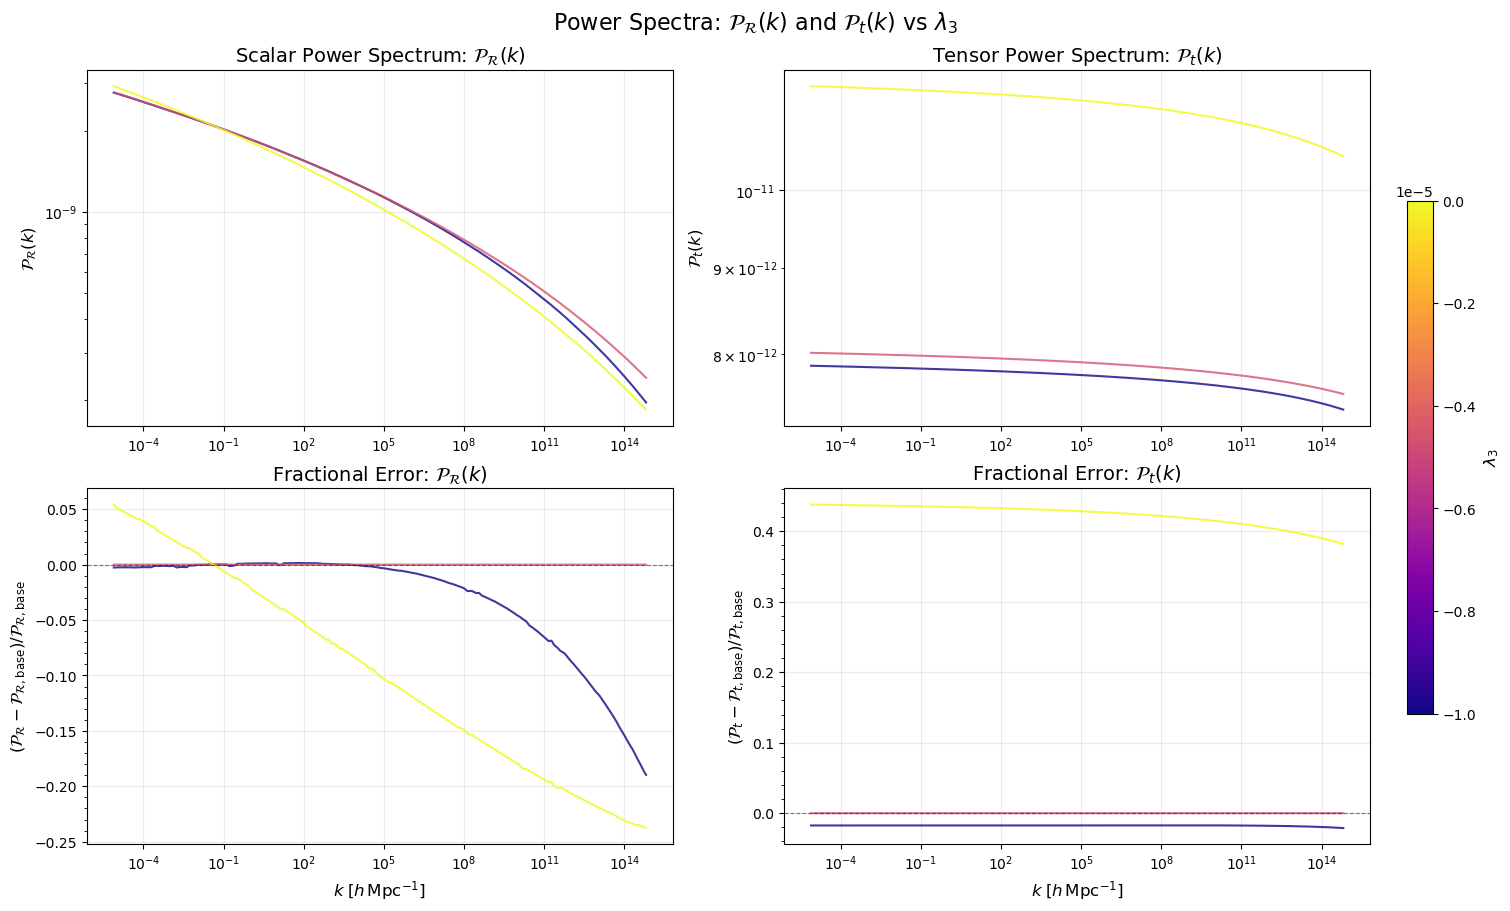

In [56]:
# 6. Power Spectra Comparison P_s(k) and P_t(k) and fractional error plots

def plot_power_spectra_with_errors(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    save_name=None,
    suptitle=None,
):
    """
    Plot Ps(k) and Pt(k) with fractional errors relative to base model.
    
    Layout: 2x2
      Top row: Ps(k), Pt(k)
      Bottom row: fractional error Ps(k), fractional error Pt(k)
    
    Conventions / units:
      - k in h/Mpc
      - Ps and Pt dimensionless
    """
    base_path = f"{base_path_root}/neqs{NEQS}"

    def load_specs_lam3(value, index=index):
        val_str = f"{value:.1e}"
        folder = f"{base_path}/lam3_{val_str}/"

        file_s = f"{folder}spec_s{index:03d}_neqs{NEQS}.dat"
        file_t = f"{folder}spec_t{index:03d}_neqs{NEQS}.dat"

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_hmpc = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])
        Pt = np.abs(data_t[:, 1])

        return k_hmpc, Ps, Pt

    # Load base model
    try:
        k_base, Ps_base, Pt_base = load_specs_lam3(base_lam3)
    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return
    
    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)

    # Colormap
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    fig, axs = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            k_hmpc, Ps, Pt = load_specs_lam3(lam3_val)

            # Check k grid consistency
            if not np.allclose(k_hmpc, k_base):
                print(f"Warning: k grid mismatch for lam3 = {lam3_val:.5e}")
                continue

            color = cmap(norm(lam3_val))

            # Fractional errors
            frac_Ps = (Ps - Ps_base) / Ps_base
            frac_Pt = (Pt - Pt_base) / Pt_base

            # Top row: actual spectra
            axs[0, 0].plot(k_hmpc, Ps, color=color, lw=1.5, alpha=0.8)
            axs[0, 1].plot(k_hmpc, Pt, color=color, lw=1.5, alpha=0.8)

            # Bottom row: fractional errors
            axs[1, 0].plot(k_hmpc, frac_Ps, color=color, lw=1.5, alpha=0.8)
            axs[1, 1].plot(k_hmpc, frac_Pt, color=color, lw=1.5, alpha=0.8)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    # Top row titles
    axs[0, 0].set_title(r"Scalar Power Spectrum: $\mathcal{P}_\mathcal{R}(k)$", fontsize=14)
    axs[0, 1].set_title(r"Tensor Power Spectrum: $\mathcal{P}_t(k)$", fontsize=14)

    # Bottom row titles
    axs[1, 0].set_title(r"Fractional Error: $\mathcal{P}_\mathcal{R}(k)$", fontsize=14)
    axs[1, 1].set_title(r"Fractional Error: $\mathcal{P}_t(k)$", fontsize=14)

    # Y-labels
    axs[0, 0].set_ylabel(r"$\mathcal{P}_\mathcal{R}(k)$", fontsize=12)
    axs[0, 1].set_ylabel(r"$\mathcal{P}_t(k)$", fontsize=12)
    axs[1, 0].set_ylabel(r"$(\mathcal{P}_\mathcal{R} - \mathcal{P}_{\mathcal{R},\rm base}) / \mathcal{P}_{\mathcal{R},\rm base}$", fontsize=12)
    axs[1, 1].set_ylabel(r"$(\mathcal{P}_t - \mathcal{P}_{t,\rm base}) / \mathcal{P}_{t,\rm base}$", fontsize=12)

    # X-labels (only bottom row)
    axs[1, 0].set_xlabel(r"$k \;[h\,{\rm Mpc}^{-1}]$", fontsize=12)
    axs[1, 1].set_xlabel(r"$k \;[h\,{\rm Mpc}^{-1}]$", fontsize=12)

    # Log scales for top row
    axs[0, 0].set_xscale("log")
    axs[0, 0].set_yscale("log")
    axs[0, 1].set_xscale("log")
    axs[0, 1].set_yscale("log")

    # Log x-scale for bottom row
    axs[1, 0].set_xscale("log")
    axs[1, 1].set_xscale("log")

    # Grid
    for ax in axs.ravel():
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # Add horizontal line at 0 for error plots
    axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # Colorbar
    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), orientation="vertical", 
                        fraction=0.02, pad=0.02)
    cbar.set_label(r"$\lambda_3$", fontsize=12)

    # Suptitle
    if suptitle is None:
        suptitle = r"Power Spectra: $\mathcal{P}_\mathcal{R}(k)$ and $\mathcal{P}_t(k)$ vs $\lambda_3$"
    fig.suptitle(suptitle, fontsize=16)

    # Save
    if save_name is None:
        save_name = f"neqs{NEQS}_power_spectra_lam3_variations.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

    
plot_power_spectra_with_errors(
NEQS=6,
lam3_values=lam3_values,
base_lam3=-4.6e-06,
base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
)


In [ ]:
#Find k range!!

def plot_power_spectra_with_errors_limitedN(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    index=0,
    k_min_plot=None,
    k_max_plot=None,
    save_name=None,
    suptitle=None,
):
    """
    Plot Ps(k) and Pt(k) with fractional errors relative to base model.

    Optional mask:
      only plot k in [k_min_plot, k_max_plot]
    """

    base_path = f"{base_path_root}/neqs{NEQS}"

    def load_specs_lam3(value, index=index):
        val_str = f"{value:.1e}"
        folder = f"{base_path}/lam3_{val_str}/"

        file_s = f"{folder}spec_s{index:03d}_neqs{NEQS}.dat"
        file_t = f"{folder}spec_t{index:03d}_neqs{NEQS}.dat"

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_hmpc = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])
        Pt = np.abs(data_t[:, 1])

        return k_hmpc, Ps, Pt

    # Load base model
    try:
        k_base, Ps_base, Pt_base = load_specs_lam3(base_lam3)
    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return

    # Apply optional k mask to base model
    mask_base = np.ones_like(k_base, dtype=bool)
    if k_min_plot is not None:
        mask_base &= (k_base >= k_min_plot)
    if k_max_plot is not None:
        mask_base &= (k_base <= k_max_plot)

    k_base = k_base[mask_base]
    Ps_base = Ps_base[mask_base]
    Pt_base = Pt_base[mask_base]

    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)

    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    fig, axs = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            k_hmpc, Ps, Pt = load_specs_lam3(lam3_val)

            # Apply same k mask
            mask = np.ones_like(k_hmpc, dtype=bool)
            if k_min_plot is not None:
                mask &= (k_hmpc >= k_min_plot)
            if k_max_plot is not None:
                mask &= (k_hmpc <= k_max_plot)

            k_hmpc = k_hmpc[mask]
            Ps = Ps[mask]
            Pt = Pt[mask]

            if len(k_hmpc) == 0:
                print(f"Skip lam3 = {lam3_val:.5e}: no data in requested k range")
                continue

            # Check masked k grid consistency
            if not np.allclose(k_hmpc, k_base):
                print(f"Warning: k grid mismatch for lam3 = {lam3_val:.5e}")
                continue

            color = cmap(norm(lam3_val))

            tiny = 1e-300
            frac_Ps = (Ps - Ps_base) / np.where(np.abs(Ps_base) > tiny, Ps_base, np.nan)
            frac_Pt = (Pt - Pt_base) / np.where(np.abs(Pt_base) > tiny, Pt_base, np.nan)

            axs[0, 0].plot(k_hmpc, Ps, color=color, lw=2.0, alpha=0.85)
            axs[0, 1].plot(k_hmpc, Pt, color=color, lw=2.0, alpha=0.85)

            axs[1, 0].plot(k_hmpc, frac_Ps, color=color, lw=2.0, alpha=0.85)
            axs[1, 1].plot(k_hmpc, frac_Pt, color=color, lw=2.0, alpha=0.85)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    axs[0, 0].set_title(r"Scalar Power Spectrum: $\mathcal{P}_\mathcal{R}(k)$", fontsize=14)
    axs[0, 1].set_title(r"Tensor Power Spectrum: $\mathcal{P}_t(k)$", fontsize=14)
    axs[1, 0].set_title(r"Fractional Error: $\mathcal{P}_\mathcal{R}(k)$", fontsize=14)
    axs[1, 1].set_title(r"Fractional Error: $\mathcal{P}_t(k)$", fontsize=14)

    axs[0, 0].set_ylabel(r"$\mathcal{P}_\mathcal{R}(k)$", fontsize=12)
    axs[0, 1].set_ylabel(r"$\mathcal{P}_t(k)$", fontsize=12)
    axs[1, 0].set_ylabel(r"$(\mathcal{P}_\mathcal{R}-\mathcal{P}_{\mathcal{R},\rm base})/\mathcal{P}_{\mathcal{R},\rm base}$", fontsize=12)
    axs[1, 1].set_ylabel(r"$(\mathcal{P}_t-\mathcal{P}_{t,\rm base})/\mathcal{P}_{t,\rm base}$", fontsize=12)

    axs[1, 0].set_xlabel(r"$k \;[h\,{\rm Mpc}^{-1}]$", fontsize=12)
    axs[1, 1].set_xlabel(r"$k \;[h\,{\rm Mpc}^{-1}]$", fontsize=12)

    axs[0, 0].set_xscale("log")
    axs[0, 0].set_yscale("log")
    axs[0, 1].set_xscale("log")
    axs[0, 1].set_yscale("log")
    axs[1, 0].set_xscale("log")
    axs[1, 1].set_xscale("log")

    for ax in axs.ravel():
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    cbar = fig.colorbar(sm, ax=axs.ravel().tolist(), orientation="vertical",
                        fraction=0.02, pad=0.02)
    cbar.set_label(r"$\lambda_3$", fontsize=12)

    if suptitle is None:
        suptitle = r"Power Spectra vs $\lambda_3$"
    fig.suptitle(suptitle, fontsize=16)

    if save_name is None:
        save_name = f"neqs{NEQS}_power_spectra_lam3_variations.png"

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    
    
plot_power_spectra_with_errors(
    NEQS=6,
    lam3_values=lam3_values,
    base_lam3=-4.6e-06,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    k_min_plot=1e-4,
    k_max_plot=1e6,
    save_name="higgs_power_spectra_zoomed.png",
    suptitle=r"Higgs Power Spectra: selected $k$ range"
)

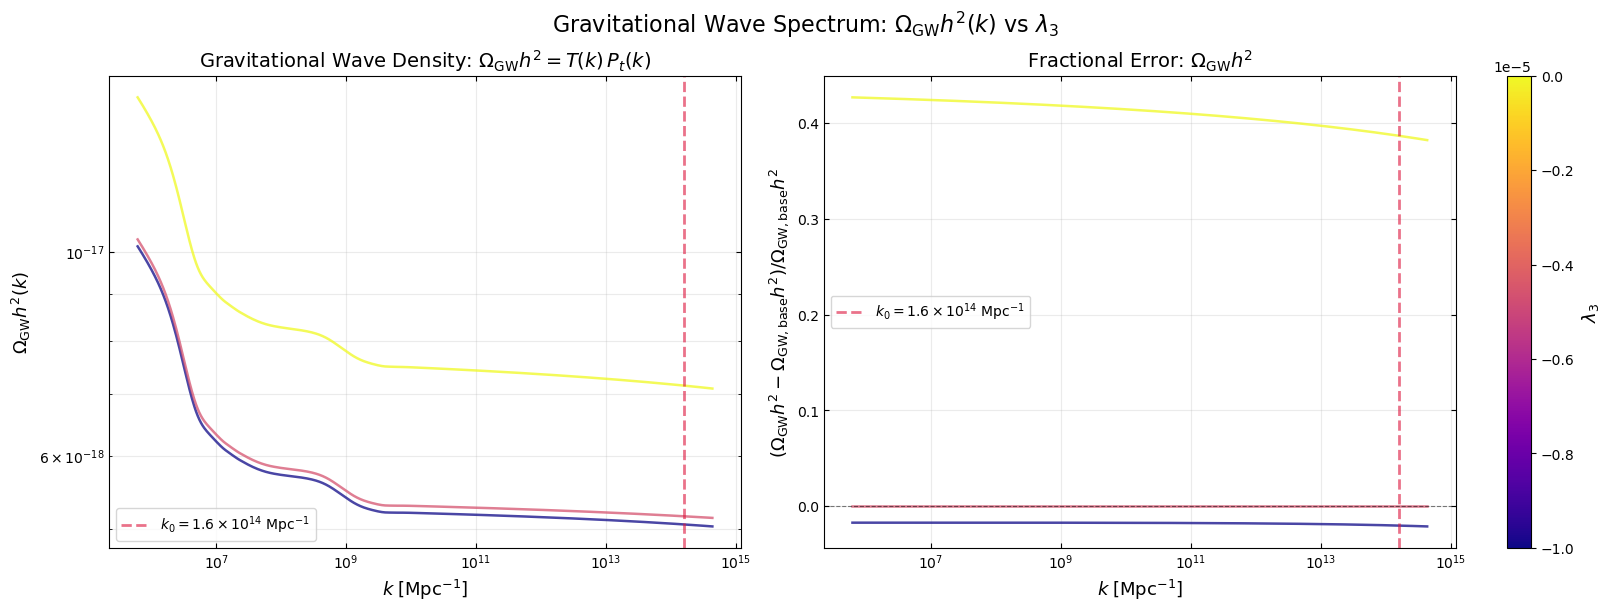

In [60]:
# 7. OmegaGWh2 and OmegaGW with fractional error plots

tf_path = Path("/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests")
tf_k= np.loadtxt(tf_path/"k_file_tf.dat")
tf_f= np.loadtxt(tf_path/"f_file_tf.dat")
tf_median= np.loadtxt(tf_path/"Tf_median.dat")
tf_k_invm = tf_f*2*np.pi/(299792458.0) #should be in inverse meters now
tf_k_invMpc = tf_k_invm * 3.085677581e22 #should now be in inverse Mpc


def plot_omegaGW_with_errors(
    NEQS,
    lam3_values,
    base_lam3,
    base_path_root,
    tf_k_invMpc,
    tf_median,
    index=0,
    h=0.67,
    k0=1.6e14,
    save_name=None,
    suptitle=None,
):
    """
    Plot Omega_GW h^2(k) with fractional errors relative to base model.
    
    Layout: 1x2
      Left: log Omega_GW h^2(k)
      Right: fractional error in Omega_GW h^2(k)
    
    Uses transfer function T(k) and primordial Pt(k).
    """
    base_path = f"{base_path_root}/neqs{NEQS}"

    def load_specs_lam3(value, index=index):
        val_str = f"{value:.1e}"
        folder = f"{base_path}/lam3_{val_str}/"

        file_s = f"{folder}spec_s{index:03d}_neqs{NEQS}.dat"
        file_t = f"{folder}spec_t{index:03d}_neqs{NEQS}.dat"

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_hmpc = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])
        Pt = np.abs(data_t[:, 1])

        return k_hmpc, Ps, Pt


    # --- Build TF interpolator ---
    tf_k = np.asarray(tf_k_invMpc)
    tf_T = np.asarray(tf_median)

    good_tf = np.isfinite(tf_k) & np.isfinite(tf_T) & (tf_k > 0) & (tf_T > 0)
    tf_k = tf_k[good_tf]
    tf_T = tf_T[good_tf]

    from scipy.interpolate import interp1d
    logT_spline = interp1d(
        np.log(tf_k),
        np.log(tf_T),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    kmin_data = tf_k.min()
    kmax_data = tf_k.max()

    # --- Load base model ---
    try:
        k_base_hmpc, _, Pt_base = load_specs_lam3(base_lam3)
        k_base_mpc = h * k_base_hmpc
        
        # Restrict to TF range
        mask_base = (k_base_mpc >= kmin_data) & (k_base_mpc <= kmax_data) & np.isfinite(Pt_base)
        k_base = k_base_mpc[mask_base]
        Pt_base_use = np.abs(Pt_base[mask_base])
        
        # Compute base Omega_GW h^2
        logT_base = logT_spline(np.log(k_base))
        T_base = np.exp(logT_base)
        OmegaGW_h2_base = T_base * Pt_base_use
        
    except FileNotFoundError:
        print(f"Base model lam3 = {base_lam3:.5e} not found!")
        return

    lam3_numeric = np.array([x[0] for x in lam3_values], dtype=float)
        
    # --- Colormap ---
    cmap = cm.plasma
    norm = mcolors.Normalize(vmin=min(lam3_numeric), vmax=max(lam3_numeric))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)

    # --- Create figure ---
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    for lam3_val in lam3_numeric:
        try:
            k_hmpc, _, Pt = load_specs_lam3(lam3_val)
            k_mpc = h * k_hmpc

            # Restrict to TF validity range
            mask = (k_mpc >= kmin_data) & (k_mpc <= kmax_data) & np.isfinite(Pt)
            if np.count_nonzero(mask) < 5:
                print(f"Skip lam3 = {lam3_val:.5e}: insufficient overlap with TF")
                continue

            k_use = k_mpc[mask]
            Pt_use = np.abs(Pt[mask])

            # Evaluate TF
            logT = logT_spline(np.log(k_use))
            T_use = np.exp(logT)

            # Compute Omega_GW h^2
            OmegaGW_h2 = T_use * Pt_use

            color = cmap(norm(lam3_val))

            # Interpolate base model onto current k grid for fractional error
            OmegaGW_h2_base_interp = np.interp(k_use, k_base, OmegaGW_h2_base)
            
            # Fractional error
            frac_error = (OmegaGW_h2 - OmegaGW_h2_base_interp) / OmegaGW_h2_base_interp

            # Left: actual Omega_GW h^2
            axs[0].loglog(k_use, OmegaGW_h2, color=color, lw=1.8, alpha=0.75)

            # Right: fractional error
            axs[1].semilogx(k_use, frac_error, color=color, lw=1.8, alpha=0.75)

        except FileNotFoundError:
            print(f"Missing data for lam3 = {lam3_val:.5e}")

    # --- Add k0 reference line ---
    for ax in axs:
        ax.axvline(k0, color="crimson", linestyle="--", lw=2, alpha=0.6,
                   label=rf"$k_0 = 1.6 \times 10^{{14}}$ Mpc$^{{-1}}$")

    # --- Labels and titles ---
    axs[0].set_xlabel(r"$k \; [{\rm Mpc}^{-1}]$", fontsize=13)
    axs[1].set_xlabel(r"$k \; [{\rm Mpc}^{-1}]$", fontsize=13)

    axs[0].set_ylabel(r"$\Omega_{\rm GW} h^2(k)$", fontsize=13)
    axs[1].set_ylabel(
        r"$(\Omega_{\rm GW}h^2 - \Omega_{\rm GW,base}h^2) / \Omega_{\rm GW,base}h^2$",
        fontsize=13
    )

    axs[0].set_title(r"Gravitational Wave Density: $\Omega_{\rm GW}h^2 = T(k) \, P_t(k)$", fontsize=14)
    axs[1].set_title(r"Fractional Error: $\Omega_{\rm GW}h^2$", fontsize=14)

    # --- Horizontal line at 0 for error plot ---
    axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # --- Grid and ticks ---
    for ax in axs:
        ax.grid(True, alpha=0.25, which="both")
        ax.tick_params(direction="in", which="both", top=True, right=True)
        ax.legend(loc='best', fontsize=10)

    # --- Colorbar ---
    cbar = fig.colorbar(sm, ax=axs, orientation="vertical", fraction=0.03, pad=0.02)
    cbar.set_label(r"$\lambda_3$", fontsize=13)

    # --- Suptitle ---
    if suptitle is None:
        suptitle = r"Gravitational Wave Spectrum: $\Omega_{\rm GW}h^2(k)$ vs $\lambda_3$"
    fig.suptitle(suptitle, fontsize=16)

    # --- Save ---
    if save_name is None:
        save_name = f"neqs{NEQS}_omegaGW_lam3_variations.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

    
    
    
plot_omegaGW_with_errors(
    NEQS=6,
    lam3_values=lam3_values,
    base_lam3=-4.6e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    tf_k_invMpc=tf_k_invMpc,
    tf_median=tf_median,
    h=0.67,
    k0=1.6e14
)
